In [1]:
#drive connection
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#zip dataset path
zip_path = '/content/drive/MyDrive/AI Workshop/Week 5/FruitinAmazon.zip'

In [4]:
#unzip the dataset file
import zipfile
import os

extract_path = '/content/drive/MyDrive/AI Workshop/Week5'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
   zip_ref.extractall(extract_path)

print("Unzipped successfully!")

Unzipped successfully!


**Implementation of an End-to-End CNN Model for Image Classification Task**

# Data Understanding and Visualization
Load and visualize the images data

In [5]:
#imports
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

In [6]:
#train dataset path
train_dir = "/content/drive/MyDrive/AI Workshop/Week5/FruitinAmazon/train"

#list of each directories inside train directory
classes = os.listdir(train_dir)
print("Classes:", classes)

Classes: ['pupunha', 'acai', 'guarana', 'graviola', 'tucuma', 'cupuacu']


In [7]:
images = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)
    images.append((cls, img_path))

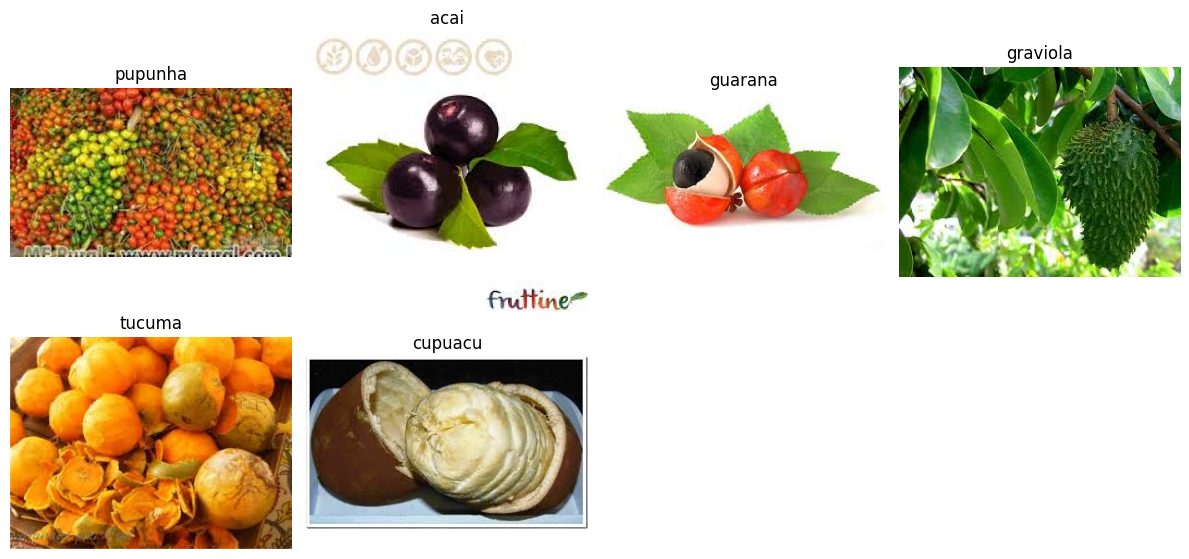

In [8]:
plt.figure(figsize=(12, 6))

for i, (cls, img_path) in enumerate(images):
    plt.subplot(2, len(images)//2 + 1, i+1)
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
#Check for Corrupted Image
corrupted_images = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except (IOError, SyntaxError):
            corrupted_images.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted_images) == 0:
    print("No corrupted images found.")

No corrupted images found.


In [10]:
#impot and setting vlaue for image data
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

In [11]:
#convert the pixel value to either 0 or 1.
rescale = tf.keras.layers.Rescaling(1./255)

In [12]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.


In [13]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 18 files for validation.


# CNN Model

In [14]:
from tensorflow.keras import layers, models

num_classes = len(classes)

model = models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
#Compile Module
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
#Train the model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True)
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.1186 - loss: 1.8569

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 596ms/step - accuracy: 0.1528 - loss: 1.8713 - val_accuracy: 0.0556 - val_loss: 1.8690
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.2396 - loss: 1.6926

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 486ms/step - accuracy: 0.2500 - loss: 1.6912 - val_accuracy: 0.1111 - val_loss: 1.6732
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 521ms/step - accuracy: 0.4861 - loss: 1.5153 - val_accuracy: 0.2222 - val_loss: 1.7298
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 627ms/step - accuracy: 0.4340 - loss: 1.3677

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 865ms/step - accuracy: 0.4583 - loss: 1.3326 - val_accuracy: 0.3889 - val_loss: 1.4783
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.6047 - loss: 1.0672

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 486ms/step - accuracy: 0.6111 - loss: 1.0813 - val_accuracy: 0.7222 - val_loss: 1.0624
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.6956 - loss: 0.9201

...

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 486ms/step - accuracy: 1.0000 - loss: 0.0153 - val_accuracy: 0.8889 - val_loss: 0.3043
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 1.0000 - loss: 0.0102

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 497ms/step - accuracy: 1.0000 - loss: 0.0103 - val_accuracy: 0.8333 - val_loss: 0.3017
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 1.0000 - loss: 0.0076

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 494ms/step - accuracy: 1.0000 - loss: 0.0085 - val_accuracy: 0.8889 - val_loss: 0.2447
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 675ms/step - accuracy: 1.0000 - loss: 0.0037 - val_accuracy: 0.9444 - val_loss: 0.2781
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - accuracy: 1.0000 - loss: 0.0024

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 843ms/step - accuracy: 1.0000 - loss: 0.0030 - val_accuracy: 0.8889 - val_loss: 0.2350
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 1.0000 - loss: 0.0015

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 644ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.9444 - val_loss: 0.1715
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 469ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.9444 - val_loss: 0.1828
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 446ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.8889 - val_loss: 0.2421
Epoch 22/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 458ms/step - accuracy: 1.0000 - loss: 7.2375e-04 - val_accuracy: 0.8889 - val_loss: 0.3227
Epoch 23/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 456ms/step - accuracy: 1.0000 - loss: 8.5717e-04 - val_accuracy: 0.8889 - val_loss: 0.3604
Epoch 24/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 794ms/step - accuracy: 1.0000 - loss: 6.2195e-04 - val_accuracy: 0.8889 - val_loss: 0.3700
Epoch 25/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 463ms/step - accuracy: 1.0000 - loss: 4.1944e-04 - val_accuracy: 0.8889 - val_loss: 0.3691
Epoch 26/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 455ms/step - accuracy: 1.0000 - loss: 3.8085e-04 - val_accur

In [17]:
#Evaluate the Model
test_loss, test_acc = model.evaluate(val_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.9444 - loss: 0.1715
Test Loss: 0.17153984308242798
Test Accuracy: 0.9444444179534912


In [18]:
#Save the Model
model.save("Week5_CNN-Model.h5")

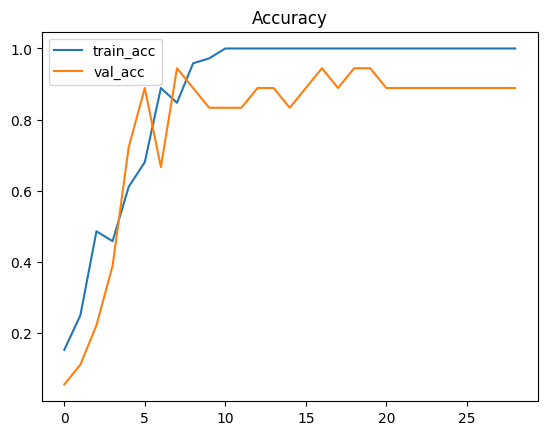

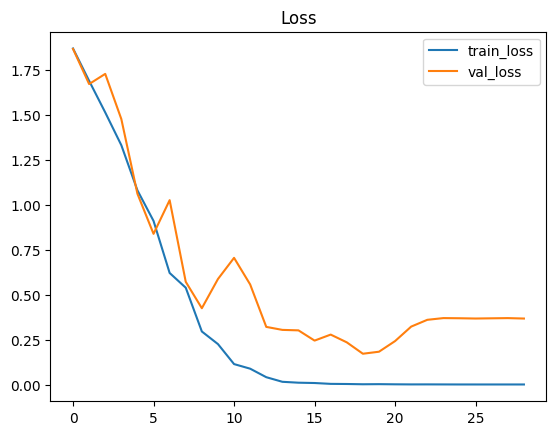

In [19]:
#Visualization of taining and validation loss and accuracy
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()

# Predictions and Classification Report

In [20]:
#Test Data
test_dir = "/content/drive/MyDrive/AI Workshop/Week5/FruitinAmazon/test"

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

#normalization
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

Found 30 files belonging to 6 classes.


In [21]:
#loss and accuracy on test data
test_loss, test_acc = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.6333 - loss: 1.3395
Test Loss: 1.3395
Test Accuracy: 0.6333


In [22]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step


In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=classes))

              precision    recall  f1-score   support

     pupunha       0.60      0.60      0.60         5
        acai       0.38      0.60      0.46         5
     guarana       0.71      1.00      0.83         5
    graviola       1.00      0.40      0.57         5
      tucuma       0.71      1.00      0.83         5
     cupuacu       1.00      0.20      0.33         5

    accuracy                           0.63        30
   macro avg       0.73      0.63      0.61        30
weighted avg       0.73      0.63      0.61        30

